# Import Libraries

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.svm import SVR
warnings.filterwarnings('ignore')

# Load Dataset

In [2]:
# Download latest version
path = kagglehub.dataset_download("mdmahfuzsumon/global-gold-price-dataset-18332026-monthly")

print("Path to dataset files:", path)

100%|██████████| 7.89k/7.89k [00:00<00:00, 3.46MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/mdmahfuzsumon/global-gold-price-dataset-18332026-monthly/versions/1


In [3]:
df_path = path + "/monthly.csv"
df = pd.read_csv(df_path)
df.head()

,Date,Price
0,1833-01,18.93
1,1833-02,18.93
2,1833-03,18.93
3,1833-04,18.93
4,1833-05,18.93


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2318 entries, 0 to 2317
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    2318 non-null   object 
 1   Price   2318 non-null   float64
dtypes: float64(1), object(1)
memory usage: 36.3+ KB


In [ ]:
df.describe()

,Price
count,2318.000000
mean,232.232352
std,508.694544
min,17.060000
25%,18.940000
50%,20.680000
75%,176.300000
max,5019.970000


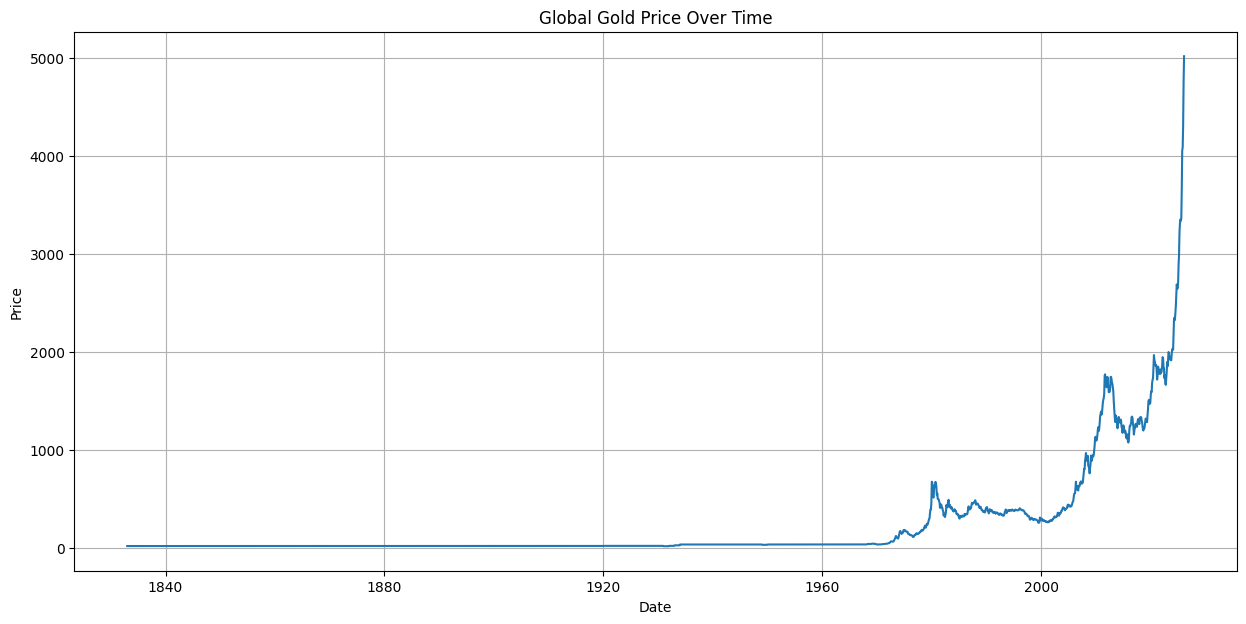

In [4]:
df['Date'] = pd.to_datetime(df['Date'])

plt.figure(figsize=(15, 7))
sns.lineplot(x='Date', y='Price', data=df)
plt.title('Global Gold Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.show()

# Predicting Gold Price with Linear Regression

For predicting a continuous value like gold price, we need a regression model. Let's use Linear Regression as a starting point. We'll need to prepare our data by extracting relevant features from the 'Date' and 'Price' columns.

In [5]:
# Ensure 'Date' is datetime (already done in previous step but good to be explicit)
df['Date'] = pd.to_datetime(df['Date'])

# Sort by date to ensure correct lag features
df = df.sort_values(by='Date').reset_index(drop=True)

# Feature Engineering: Create lag features for price
# Lag 1 month price
df['Price_Lag1'] = df['Price'].shift(1)

# Create time-based features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# Drop rows with NaN values resulting from lag features
df_model = df.dropna().copy()

display(df_model.head())

,Date,Price,Price_Lag1,Year,Month
1,1833-02-01,18.93,18.93,1833,2
2,1833-03-01,18.93,18.93,1833,3
3,1833-04-01,18.93,18.93,1833,4
4,1833-05-01,18.93,18.93,1833,5
5,1833-06-01,18.93,18.93,1833,6


In [6]:
# Define features (X) and target (y)
X = df_model[['Price_Lag1', 'Year', 'Month']]
y = df_model['Price']

# Split the data into training and testing sets
# Using a time-series split would be more appropriate for time-series data,
# but for simplicity and demonstration, we'll use a standard train_test_split here.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nModel Evaluation:")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2) Score: {r2:.2f}")

Training data shape: (1853, 3)
Testing data shape: (464, 3)

Model Evaluation:
Mean Squared Error (MSE): 574.14
R-squared (R2) Score: 1.00


In [10]:
# Let's find the last known date and price to predict the next month
last_date = df_model['Date'].max()
last_price = df_model[df_model['Date'] == last_date]['Price'].iloc[0]

# Calculate the next month's date
next_month_date = last_date + pd.DateOffset(months=1)

# Create a new DataFrame for the new input
new_data = pd.DataFrame({
    'Price_Lag1': [last_price],  # Use the last known price as the lag for the next prediction
    'Year': [next_month_date.year],
    'Month': [next_month_date.month]
})

print(f"Predicting gold price for: {next_month_date.strftime('%Y-%m')}")
print("Input features for prediction:")
display(new_data)

# Predict the gold price using the trained Linear Regression model
predicted_price = model.predict(new_data)

print(f"\nPredicted Gold Price for {next_month_date.strftime('%Y-%m')}: ${predicted_price[0]:.2f}")

Predicting gold price for: 2026-03
Input features for prediction:


,Price_Lag1,Year,Month
0,5019.97,2026,3



Predicted Gold Price for 2026-03: $5121.82


The model has been trained and evaluated. The MSE and R2 score provide an indication of how well the linear regression model predicts gold prices based on the previous month's price, year, and month.

# Predicting with SVR

In [8]:
SVR_model = SVR()
SVR_model.fit(X_train, y_train)
y_pred_svr = SVR_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred_svr)
r2 = r2_score(y_test, y_pred_svr)
print(f"\nModel Evaluation:")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2) Score: {r2:.2f}")


Model Evaluation:
Mean Squared Error (MSE): 174875.14
R-squared (R2) Score: 0.15
